<a href="https://colab.research.google.com/github/parames9-1761/PARAMESWARA-REDDY-AVULA/blob/main/AI_Face_Recognition_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Face Recognition System

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.6/205.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.5 MB/s eta 0:00:00
26-10-08 14:09:21 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.

26-10-08 14:09:26 - Directory /root/.deepf

Saving IMG_20260619_134732[1].jpg to IMG_20260619_134732[1].jpg

Uploaded file: IMG_20260619_134732[1].jpg


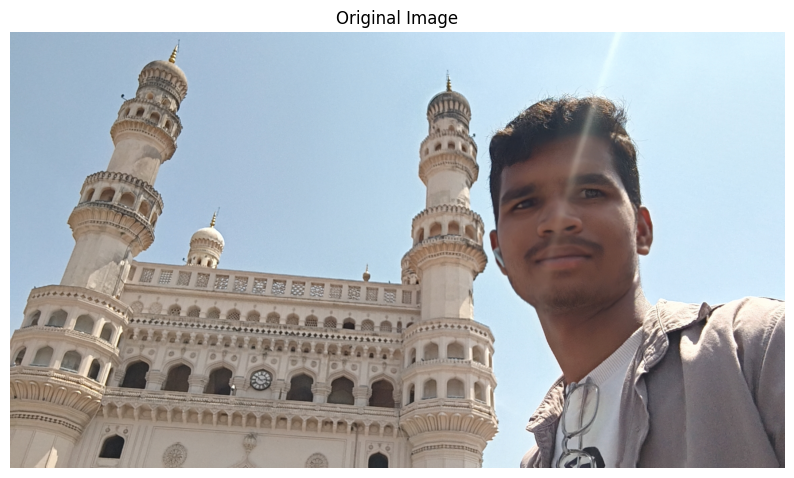


Analyzing face...
26-10-08 14:10:22 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 92.6MB/s]



       EMOTION RESULT
Detected Emotion: NEUTRAL

Emotion Confidence:
Angry      : 11.65%
Disgust    : 0.02%
Fear       : 1.96%
Happy      : 4.49%
Sad        : 24.90%
Surprise   : 0.02%
Neutral    : 56.96%


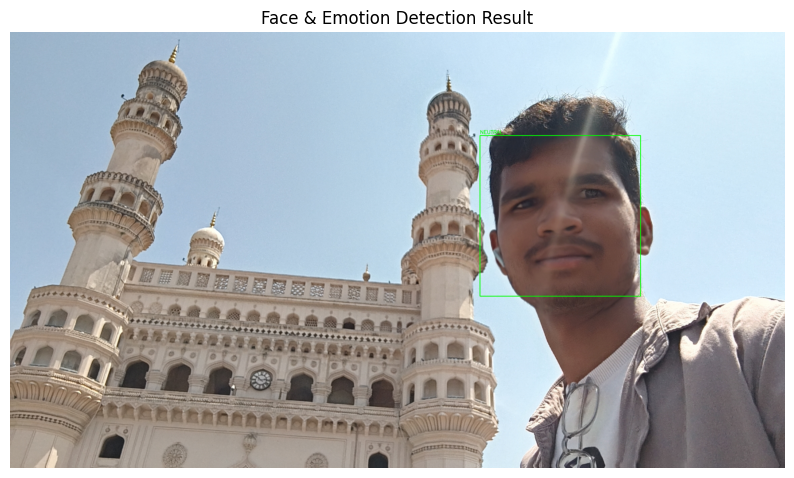

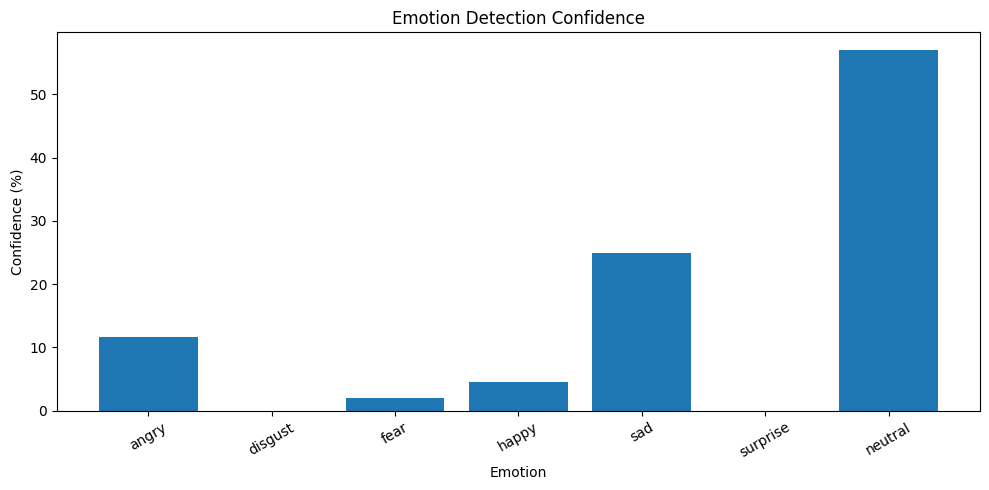


Project completed successfully!


In [1]:
# ============================================
# FACE & EMOTION DETECTION PROJECT
# ============================================

# Install libraries first if needed:
!pip install deepface opencv-python-headless matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace
from google.colab import files

# --------------------------------------------
# 1. Upload Image
# --------------------------------------------

print("Please upload an image...")

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("\nUploaded file:", image_path)

# --------------------------------------------
# 2. Read Image
# --------------------------------------------

image = cv2.imread(image_path)

if image is None:
    print("Error: Could not read image.")
else:

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ----------------------------------------
    # 3. Display Original Image
    # ----------------------------------------

    plt.figure(figsize=(10, 7))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Original Image")
    plt.show()

    # ----------------------------------------
    # 4. Emotion Analysis
    # ----------------------------------------

    print("\nAnalyzing face...")

    result = DeepFace.analyze(
        img_path=image_path,
        actions=["emotion"],
        enforce_detection=False
    )

    # DeepFace can return either a dictionary
    # or a list containing dictionaries

    if isinstance(result, list):
        result = result[0]

    # ----------------------------------------
    # 5. Get Dominant Emotion
    # ----------------------------------------

    dominant_emotion = result["dominant_emotion"]

    print("\n================================")
    print("       EMOTION RESULT")
    print("================================")

    print(
        "Detected Emotion:",
        dominant_emotion.upper()
    )

    # ----------------------------------------
    # 6. Get Confidence Values
    # ----------------------------------------

    emotions = result["emotion"]

    print("\nEmotion Confidence:")

    for name, confidence in emotions.items():
        print(
            f"{name.capitalize():10} : "
            f"{confidence:.2f}%"
        )

    # ----------------------------------------
    # 7. Face Coordinates
    # ----------------------------------------

    region = result["region"]

    x = region["x"]
    y = region["y"]
    w = region["w"]
    h = region["h"]

    # ----------------------------------------
    # 8. Draw Face Rectangle
    # ----------------------------------------

    output = image.copy()

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    # ----------------------------------------
    # 9. Add Emotion Text
    # ----------------------------------------

    label = dominant_emotion.upper()

    cv2.putText(
        output,
        label,
        (x, max(y - 10, 30)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # ----------------------------------------
    # 10. Display Final Result
    # ----------------------------------------

    output_rgb = cv2.cvtColor(
        output,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(10, 7))

    plt.imshow(output_rgb)

    plt.axis("off")

    plt.title(
        "Face & Emotion Detection Result"
    )

    plt.show()

    # ----------------------------------------
    # 11. Emotion Graph
    # ----------------------------------------

    names = list(emotions.keys())
    values = list(emotions.values())

    plt.figure(figsize=(10, 5))

    plt.bar(names, values)

    plt.xlabel("Emotion")
    plt.ylabel("Confidence (%)")

    plt.title(
        "Emotion Detection Confidence"
    )

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

    print("\nProject completed successfully!")